# GDP Per Capita: Exploring and Predicting Economic Growth

This project looks at World Bank GDP per capita data for 8 countries (United States, United
Kingdom, China, Brazil, Germany, Pakistan, Turkiye, Saudi Arabia) from 2016 to 2025, following
the CRISP-DM process.

## Questions I want to answer

1. How has GDP per capita changed across these countries, and how is it distributed?
2. How closely do nominal and PPP-adjusted GDP per capita match up?
3. Which countries have similar economic growth patterns?
4. Can I predict whether a country's GDP per capita will go up or down next year?


## 1. Data Understanding (Gather)

Load the raw data and see what it looks like.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_PATH = "P_Data_Extract_From_World_Development_Indicators.xlsx"


def load_gdp_data(path):
    """Load the raw wide-format GDP-per-capita extract from the 'Data' sheet."""
    return pd.read_excel(path, sheet_name="Data")


raw_df = load_gdp_data(DATA_PATH)
print("Shape:", raw_df.shape)
raw_df.head()


Shape: (21, 14)


,Series Name,Series Code,Country Name,Country Code,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,GDP per capita (current US$),NY.GDP.PCAP.CD,United States,USA,57976.628204,60047.719073,62875.666138,65227.956591,64465.297142,71441.231981,78008.689581,82586.784771,86169.664158,90026.516301
1,GDP per capita (current US$),NY.GDP.PCAP.CD,United Kingdom,GBR,41258.537429,40918.052087,43704.316230,43160.684397,40815.125536,47695.649152,47034.779562,49919.689662,53341.313109,57601.962120
2,GDP per capita (current US$),NY.GDP.PCAP.CD,China,CHN,8254.868593,8979.676527,10085.663815,10342.900952,10627.463799,12887.435724,12970.605641,12951.178240,13293.116227,13861.970224
3,GDP per capita (current US$),NY.GDP.PCAP.CD,Brazil,BRA,8836.286527,10080.509282,9300.661649,9029.833267,7074.193783,7972.536650,9281.333344,10377.589279,10310.548697,10713.285687
4,GDP per capita (current US$),NY.GDP.PCAP.CD,Germany,DEU,42948.938193,45553.934150,48916.168661,47656.199740,47394.873450,52349.245999,50506.517964,54776.766824,56103.732318,60496.435082


The `Series - Metadata` sheet just documents where the data comes from (World Bank, CC BY-4.0
license), so it's not loaded as a dataframe. The `Data` sheet is in wide format — one row per
country/series, one column per year — so it needs reshaping before it's useful.


## 2. Data Preparation (Assess & Clean)

Reshape the data into a tidy format (one row per country and year), then check for missing
values and duplicates.


In [2]:
SERIES_NAME_MAP = {
    "GDP per capita (current US$)": "gdp_current_usd",
    "GDP per capita, PPP (current international $)": "gdp_ppp",
}


def reshape_to_long(df):
    """Melt wide year columns and pivot Series Name into gdp_current_usd/gdp_ppp columns."""
    year_columns = df.columns[4:]
    long_df = df.melt(
        id_vars=["Series Name", "Country Name"],
        value_vars=year_columns,
        var_name="year_label",
        value_name="value",
    )
    long_df["year"] = long_df["year_label"].str.extract(r"(\d{4})").astype(int)
    long_df["series"] = long_df["Series Name"].map(SERIES_NAME_MAP)
    long_df = long_df.rename(columns={"Country Name": "country"})
    wide = long_df.pivot_table(
        index=["country", "year"], columns="series", values="value"
    ).reset_index()
    wide.columns.name = None
    return wide.sort_values(["country", "year"]).reset_index(drop=True)


gdp_df = reshape_to_long(raw_df)
print("Shape:", gdp_df.shape)
gdp_df.head()


Shape: (80, 4)


,country,year,gdp_current_usd,gdp_ppp
0,Brazil,2016,8836.286527,14309.206149
1,Brazil,2017,10080.509282,14559.048890
2,Brazil,2018,9300.661649,15463.742639
3,Brazil,2019,9029.833267,16069.838015
4,Brazil,2020,7074.193783,16101.618306


In [3]:
print("Dtypes:\n", gdp_df.dtypes, sep="")
print("\nDuplicate (country, year) rows:", gdp_df.duplicated(subset=["country", "year"]).sum())
print("Missing values per column:\n", gdp_df.isna().sum(), sep="")
n_countries = gdp_df["country"].nunique()
n_years = gdp_df["year"].nunique()
print(f"\nCountries: {n_countries} | Years: {n_years}")
print(f"Expected rows (countries x years): {n_countries * n_years}")


Dtypes:
country                str
year                 int64
gdp_current_usd    float64
gdp_ppp            float64
dtype: object

Duplicate (country, year) rows: 0
Missing values per column:
country            0
year               0
gdp_current_usd    0
gdp_ppp            0
dtype: int64

Countries: 8 | Years: 10
Expected rows (countries x years): 80


No duplicates and no missing values, so no cleaning was needed beyond the reshape above.


## 3. Exploratory Data Analysis (Analyze & Visualize)


In [4]:
gdp_df.describe()


,year,gdp_current_usd,gdp_ppp
count,80.000000,80.000000,80.000000
mean,2020.500000,29216.277959,41285.618344
std,2.890403,24094.307083,24440.209563
min,2016.000000,1278.397352,4630.731507
25%,2018.000000,9611.897094,18219.535260
50%,2020.500000,20433.581899,45205.703374
75%,2023.000000,47666.062093,61247.733205
max,2025.000000,90026.516301,90026.516301


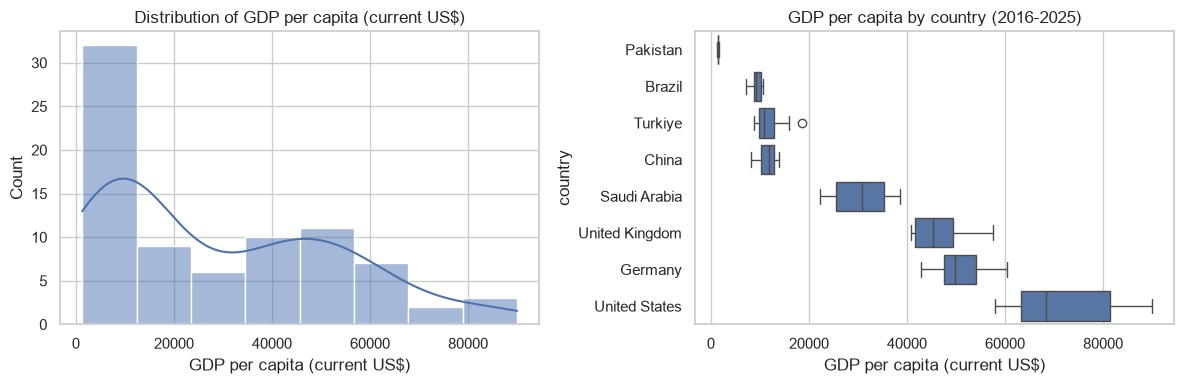

Skewness of gdp_current_usd: 0.66


In [5]:
def plot_gdp_distribution(df):
    """Plot a histogram and a per-country boxplot of GDP per capita (current US$)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df["gdp_current_usd"], kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title("Distribution of GDP per capita (current US$)")
    axes[0].set_xlabel("GDP per capita (current US$)")

    order = df.groupby("country")["gdp_current_usd"].median().sort_values().index
    sns.boxplot(data=df, y="country", x="gdp_current_usd", order=order, ax=axes[1])
    axes[1].set_title("GDP per capita by country (2016-2025)")
    axes[1].set_xlabel("GDP per capita (current US$)")

    plt.tight_layout()
    plt.show()


plot_gdp_distribution(gdp_df)
print(f"Skewness of gdp_current_usd: {gdp_df['gdp_current_usd'].skew():.2f}")


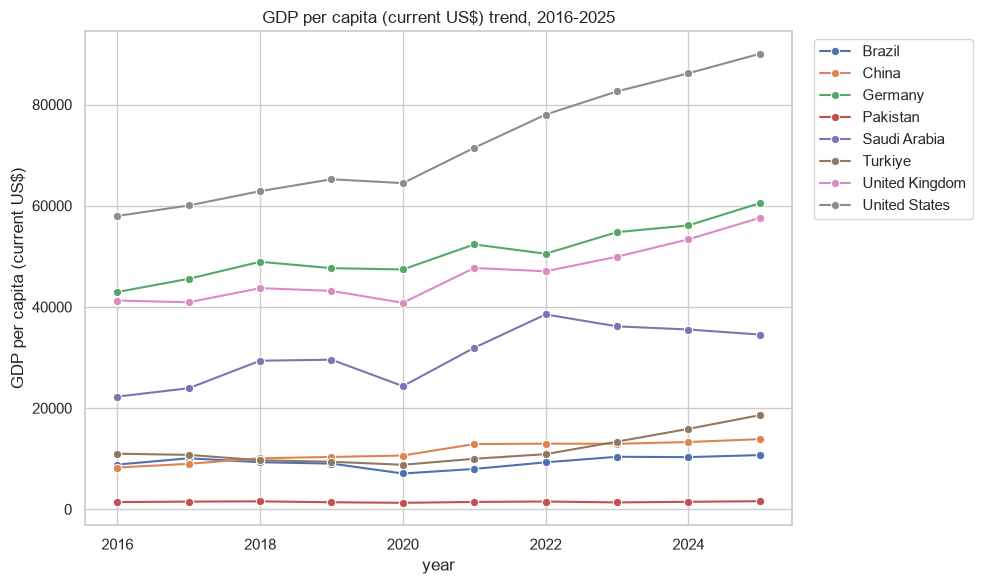

In [6]:
def plot_country_trends(df):
    """Line-plot each country's GDP per capita (current US$) trend, 2016-2025."""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="year", y="gdp_current_usd", hue="country", marker="o")
    plt.title("GDP per capita (current US$) trend, 2016-2025")
    plt.ylabel("GDP per capita (current US$)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_country_trends(gdp_df)


**Q1:** GDP per capita is right-skewed (skewness ≈ 0.66) — most countries cluster lower, while
the US pulls the top end up. There's a clear gap between the higher-income countries (US,
Germany, UK) and lower-income ones like Pakistan. Every country grew overall, but not every year
was positive — Brazil, Turkiye, and Saudi Arabia all dipped around 2020.


Correlation between nominal and PPP GDP per capita: 0.910


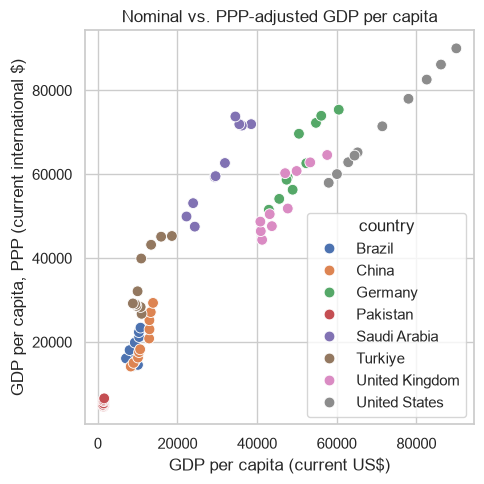

,nominal_rank,ppp_rank,rank_change
country,,,
United States,1,1,0
Germany,2,2,0
United Kingdom,3,4,-1
Saudi Arabia,4,3,1
Turkiye,5,5,0
China,6,6,0
Brazil,7,7,0
Pakistan,8,8,0


In [7]:
correlation = gdp_df[["gdp_current_usd", "gdp_ppp"]].corr().iloc[0, 1]
print(f"Correlation between nominal and PPP GDP per capita: {correlation:.3f}")

plt.figure(figsize=(5, 5))
sns.scatterplot(data=gdp_df, x="gdp_current_usd", y="gdp_ppp", hue="country", s=60)
plt.title("Nominal vs. PPP-adjusted GDP per capita")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("GDP per capita, PPP (current international $)")
plt.tight_layout()
plt.show()

latest_year = gdp_df["year"].max()
latest = gdp_df[gdp_df["year"] == latest_year].set_index("country")
rank_comparison = pd.DataFrame({
    "nominal_rank": latest["gdp_current_usd"].rank(ascending=False).astype(int),
    "ppp_rank": latest["gdp_ppp"].rank(ascending=False).astype(int),
})
rank_comparison["rank_change"] = rank_comparison["nominal_rank"] - rank_comparison["ppp_rank"]
rank_comparison.sort_values("nominal_rank")


**Q2:** Nominal and PPP GDP per capita are strongly correlated (r = 0.91), so rankings mostly
agree. The one exception: the UK and Saudi Arabia swap places once purchasing power is taken
into account, since Saudi Arabia's lower domestic prices push its PPP-adjusted value above the
UK's despite a lower nominal figure.


Explained variance ratio: [0.995 0.003]


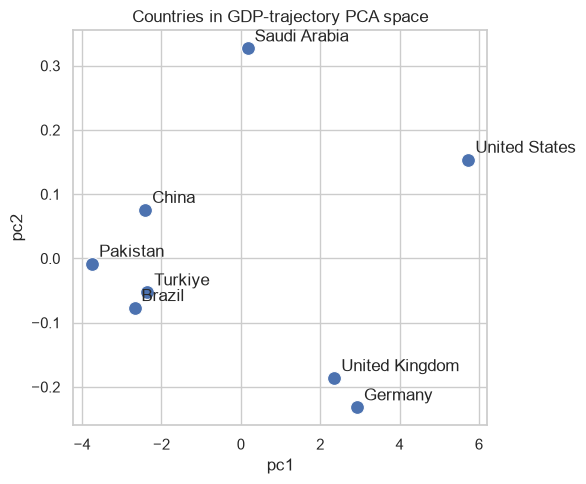

In [8]:
def compute_country_pca(df, value_col="gdp_current_usd", n_components=2):
    """Run PCA over each country's standardized yearly GDP series to reveal trajectory shape."""
    pivot = df.pivot(index="country", columns="year", values=value_col)
    scaled = StandardScaler().fit_transform(pivot)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    components = pca.fit_transform(scaled)
    columns = [f"pc{i + 1}" for i in range(n_components)]
    scores = pd.DataFrame(components, columns=columns, index=pivot.index)
    return scores, pca


pca_scores, pca_model = compute_country_pca(gdp_df)
print("Explained variance ratio:", np.round(pca_model.explained_variance_ratio_, 3))

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_scores, x="pc1", y="pc2", s=100)
for country, row in pca_scores.iterrows():
    plt.annotate(country, (row["pc1"], row["pc2"]), xytext=(5, 5), textcoords="offset points")
plt.title("Countries in GDP-trajectory PCA space")
plt.tight_layout()
plt.show()


**Q3:** The first PCA component explains 99.5% of the variance and basically just ranks
countries by income level (Pakistan/Turkiye/China/Brazil low, Saudi Arabia in the middle, UK/
Germany/US high). The second component is tiny, but it clearly separates out Saudi Arabia, whose
GDP per capita is far more volatile (oil-driven) than everyone else's steadier growth.


## 4. Modeling (Model & Evaluate)

I'll treat Q4 as a classification problem: will a country's GDP per capita be higher next year,
yes or no? That way accuracy, precision, and recall all make sense.

Note: with only 8 countries and about 8 usable transitions each (~64 rows), this is a small
dataset, so the results below are more of a demo of the pipeline than a real forecasting tool.


In [9]:
def build_growth_features(df):
    """Engineer year-over-year growth and a next-year growth-direction label per country-year."""
    df = df.sort_values(["country", "year"]).copy()
    df["yoy_growth_pct"] = df.groupby("country")["gdp_current_usd"].pct_change() * 100
    df["next_year_gdp"] = df.groupby("country")["gdp_current_usd"].shift(-1)
    df["growth_up_next_year"] = (df["next_year_gdp"] > df["gdp_current_usd"]).astype(int)
    return df.dropna(subset=["yoy_growth_pct", "next_year_gdp"]).reset_index(drop=True)


modeling_df = build_growth_features(gdp_df)
print("Shape:", modeling_df.shape)
print("Class balance:\n", modeling_df["growth_up_next_year"].value_counts(), sep="")
preview_columns = ["country", "year", "gdp_current_usd", "yoy_growth_pct", "growth_up_next_year"]
modeling_df[preview_columns].head(10)


Shape: (64, 7)
Class balance:
growth_up_next_year
1    42
0    22
Name: count, dtype: int64


,country,year,gdp_current_usd,yoy_growth_pct,growth_up_next_year
0,Brazil,2017,10080.509282,14.080833,0
1,Brazil,2018,9300.661649,-7.736193,0
2,Brazil,2019,9029.833267,-2.911926,0
3,Brazil,2020,7074.193783,-21.657537,1
4,Brazil,2021,7972.536650,12.698873,1
5,Brazil,2022,9281.333344,16.416315,1
6,Brazil,2023,10377.589279,11.811406,0
7,Brazil,2024,10310.548697,-0.646013,1
8,China,2017,8979.676527,8.780369,1
9,China,2018,10085.663815,12.316560,1


I one-hot encoded `country` instead of label-encoding it, since country names have no natural
order and label encoding would wrongly imply one.


In [10]:
FEATURE_COLUMNS = ["gdp_current_usd", "gdp_ppp", "yoy_growth_pct"]


def prepare_model_inputs(df):
    """One-hot encode country and assemble the feature matrix and target vector."""
    features = pd.get_dummies(df[FEATURE_COLUMNS + ["country"]], columns=["country"])
    target = df["growth_up_next_year"]
    return features, target


X, y = prepare_model_inputs(modeling_df)
print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (64, 11)


,gdp_current_usd,gdp_ppp,yoy_growth_pct,country_Brazil,country_China,country_Germany,country_Pakistan,country_Saudi Arabia,country_Turkiye,country_United Kingdom,country_United States
0,10080.509282,14559.048890,14.080833,True,False,False,False,False,False,False,False
1,9300.661649,15463.742639,-7.736193,True,False,False,False,False,False,False,False
2,9029.833267,16069.838015,-2.911926,True,False,False,False,False,False,False,False
3,7074.193783,16101.618306,-21.657537,True,False,False,False,False,False,False,False
4,7972.536650,18075.706005,12.698873,True,False,False,False,False,False,False,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 48 | Test size: 16


In [12]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, name):
    """Fit a classifier and return it with its metrics dict and confusion matrix."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    cm = confusion_matrix(y_test, y_pred)
    return model, metrics, cm


candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=4, random_state=RANDOM_STATE
    ),
}

fitted_models = {}
confusion_matrices = {}
all_metrics = []
for name, model in candidate_models.items():
    fitted_model, metrics, cm = evaluate_classifier(model, X_train, y_train, X_test, y_test, name)
    fitted_models[name] = fitted_model
    confusion_matrices[name] = cm
    all_metrics.append(metrics)

results_df = pd.DataFrame(all_metrics).set_index("model")
results_df


,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.5000,0.571429,0.8,0.666667
Random Forest,0.6875,0.666667,1.0,0.800000


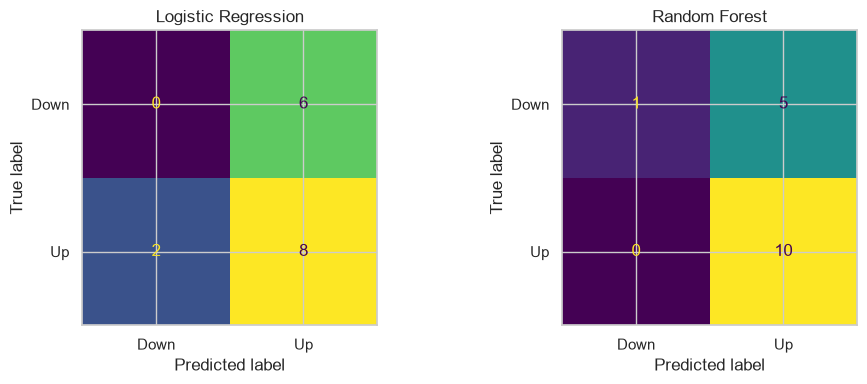

Selected final model (highest F1 on the test set): Random Forest


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

final_model_name = results_df["f1"].idxmax()
final_model = fitted_models[final_model_name]
print(f"Selected final model (highest F1 on the test set): {final_model_name}")


**Q4:** Random Forest did better than Logistic Regression (68.75% vs. 50% accuracy, F1 of 0.80
vs. 0.67), so I picked Random Forest as the final model.

- **Accuracy** — overall percent of correct predictions.
- **Recall** — of the years that actually grew, how many the model caught.
- **Precision** — of the years predicted to grow, how many actually did.

One thing worth noting: the test set had 10 "grow" years and only 6 "shrink" years, so a model
that always guesses "grow" would already get 62.5% accuracy for free. Looking at the confusion
matrices, that's basically what both models are doing — Random Forest only caught 1 of the 6
actual shrink years, and Logistic Regression caught 0. So the accuracy numbers look decent, but
neither model is actually good at spotting downturns, which is a good reminder that accuracy
alone doesn't tell the whole story.


## 5. Trying a New Scenario

Say I want to know if Pakistan's GDP per capita will keep growing next year. I don't have real
data for that year yet, so I estimate it from Pakistan's recent trend and feed it into the model.


In [14]:
def build_next_year_scenario(df, country, growth_rate_pct=None):
    """Extrapolate a plausible next-year (gdp_usd, gdp_ppp, yoy_growth_pct) for `country`."""
    country_df = df[df["country"] == country].sort_values("year")
    latest = country_df.iloc[-1]
    if growth_rate_pct is None:
        growth_rate_pct = country_df["gdp_current_usd"].pct_change().iloc[-3:].mean() * 100
    projected_usd = latest["gdp_current_usd"] * (1 + growth_rate_pct / 100)
    ppp_ratio = latest["gdp_ppp"] / latest["gdp_current_usd"]
    projected_ppp = projected_usd * ppp_ratio
    return projected_usd, projected_ppp, growth_rate_pct


def predict_growth_scenario(model, feature_columns, country, gdp_usd, gdp_ppp, yoy_growth_pct):
    """Build one scenario feature row and return the model's (prediction, probability)."""
    scenario = pd.DataFrame(0.0, index=[0], columns=feature_columns)
    scenario.loc[0, "gdp_current_usd"] = gdp_usd
    scenario.loc[0, "gdp_ppp"] = gdp_ppp
    scenario.loc[0, "yoy_growth_pct"] = yoy_growth_pct
    country_col = f"country_{country}"
    if country_col in scenario.columns:
        scenario.loc[0, country_col] = 1.0
    prediction = model.predict(scenario)[0]
    probability = model.predict_proba(scenario)[0][1]
    return prediction, probability


scenario_country = "Pakistan"
projected_usd, projected_ppp, growth_rate = build_next_year_scenario(gdp_df, scenario_country)
print(
    f"Projected next-year GDP per capita for {scenario_country}: "
    f"${projected_usd:,.2f} (current US$), implied {growth_rate:.2f}% YoY growth"
)

prediction, probability = predict_growth_scenario(
    final_model, X.columns, scenario_country, projected_usd, projected_ppp, growth_rate
)
direction = "grow" if prediction == 1 else "shrink"
print(
    f"Model prediction: {scenario_country}'s GDP per capita will {direction} the following year "
    f"(P(grow) = {probability:.2f})"
)


Projected next-year GDP per capita for Pakistan: $1,622.82 (current US$), implied 1.69% YoY growth
Model prediction: Pakistan's GDP per capita will grow the following year (P(grow) = 0.70)


Based on Pakistan's recent trend (~1.7%/year growth), I projected a GDP per capita of about
$1,623 for next year, and the model predicts growth with 70% probability.

This prediction only makes sense for Pakistan, since it's one of the 8 countries the model was
trained on — it wouldn't be valid to apply this model to a country it has never seen.


## 6. Conclusion

1. GDP per capita is right-skewed, with a clear gap between higher- and lower-income countries
   in this sample.
2. Nominal and PPP GDP per capita are strongly correlated, though PPP does reorder the UK and
   Saudi Arabia.
3. PCA shows countries mostly separate by income level, with Saudi Arabia standing out for its
   more volatile growth.
4. A Random Forest model predicts GDP growth direction reasonably well overall, but struggles to
   catch actual downturns — a good reminder that accuracy alone doesn't tell the whole story.

With more countries, more years, and more indicators, this analysis (and the model) could be
made a lot more robust.
